# Setup

In [224]:
%run notebook_setup.py

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import polars as pl
import pandas as pd
import logging
import gc
import random
import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

from src.config.dir_config import OUTPUT_PATH_DEMAND_SUMMARY
from src.config.bigquery_config import CREDENTIALS_GBQ, PROJECT_ID_GBQ
from src.utils.read_data import read_data
from src.utils.setup_logging import setup_logging
from src.utils.create_week_date import add_week_start_date
from src.utils.export_as_excel import export_dataframes_as_tables


import logging

setup_logging()

Now you can import modules from the project root: /bi/workspace/Projects/Forecast/forecast


In [225]:
def calc_wape(total_error_abs, total_sales):
    return round(total_error_abs / total_sales, 4) if total_sales != 0 else np.nan

def calc_bias(total_error, total_sales):
    return round(total_error / total_sales, 4) if total_sales != 0 else np.nan

def calc_mae(error_abs):
    if len(error_abs) == 0:
        return np.nan
    return round(np.mean(error_abs), 4)

def calc_rmse(error):
    if len(error) == 0:
        return np.nan
    return round(np.sqrt(np.mean(np.square(error))), 4)

In [226]:
def eval_forecast(df, forecast_dict):
    """
    Calcula WAPE, BIAS, MAE y RMSE para cada forecast usando
    las funciones definidas y validando con distintas columnas de ventas reales.
    
    Args:
        df (pd.DataFrame): dataframe con ventas reales y forecasts
        forecast_dict (dict): diccionario {forecast_col: real_col}
    
    Returns:
        pd.DataFrame con métricas por método
    """
    results = []

    for forecast_col, real_col in forecast_dict.items():
        actual = df[real_col].fillna(0).astype(float)
        forecast = df[forecast_col].fillna(0).astype(float)

        error = forecast - actual
        error_abs = np.abs(error)

        total_error_abs = error_abs.sum()
        total_error = error.sum()
        total_sales = actual.sum()

        results.append({
            "forecast": forecast_col,
            "tipo_venta_real": real_col,
            "wape": calc_wape(total_error_abs, total_sales),
            "bias": calc_bias(total_error, total_sales),
            "mae": calc_mae(error_abs),
            "rmse": calc_rmse(error)
        })
    
    return pd.DataFrame(results)

In [227]:
import numpy as np
import pandas as pd
from numba import njit, prange, set_num_threads

# ======================
#   Núcleos Numba
# ======================

@njit(cache=True, nogil=True, parallel=True)
def ses_ragged(values, starts, ends, alpha, out):
    ng = starts.shape[0]
    for g in prange(ng):
        s = starts[g]; e = ends[g]
        n = e - s
        if n <= 0:
            continue
        out[s] = values[s]
        for i in range(s + 1, e):
            out[i] = alpha * values[i - 1] + (1.0 - alpha) * out[i - 1]

@njit(cache=True, nogil=True, parallel=True)
def holt_ragged(values, starts, ends, alpha, beta, out):
    ng = starts.shape[0]
    for g in prange(ng):
        s = starts[g]; e = ends[g]
        n = e - s
        if n <= 0:
            continue
        if n == 1:
            out[s] = values[s]
            continue
        level = values[s]
        trend = values[s + 1] - values[s]
        if trend < 1e-6:
            trend = 1e-6
        out[s] = level
        out[s + 1] = level + trend
        for i in range(s + 2, e):
            prev_level = level
            level = alpha * values[i - 1] + (1.0 - alpha) * (level + trend)
            trend = beta * (level - prev_level) + (1.0 - beta) * trend
            v = level + trend
            out[i] = v if v > 0.0 else 0.0

@njit(cache=True, nogil=True, parallel=True)
def croston_ragged(values, starts, ends, alpha, bias_adj, out):
    ng = starts.shape[0]
    for g in prange(ng):
        s = starts[g]; e = ends[g]
        a = 0.0      # tamaño de demanda
        p = 1.0      # intervalo medio entre demandas
        tau = 1      # tiempo desde la última demanda
        initialized = False
        for i in range(s, e):
            y = values[i]
            if y > 0.0:
                if not initialized:
                    a = y
                    p = tau
                    initialized = True
                else:
                    a = a + alpha * (y - a)
                    p = p + alpha * (tau - p)
                tau = 1
            else:
                tau += 1
            if initialized:
                f = a / p
                if bias_adj:
                    f = f * (1.0 - alpha / 2.0)  # corrección SBA
                out[i] = f
            else:
                out[i] = 0.0

@njit(cache=True, nogil=True, parallel=True)
def tsb_ragged(values, starts, ends, alpha_d, alpha_p, out):
    ng = starts.shape[0]
    for g in prange(ng):
        s = starts[g]; e = ends[g]
        z = 0.0      # tamaño de demanda (solo cuando hay demanda)
        p = 0.0      # probabilidad de demanda
        initialized = False
        for i in range(s, e):
            y = values[i]
            d = 1.0 if y > 0.0 else 0.0
            if not initialized:
                z = y if d == 1.0 else 0.0
                p = d
                initialized = True
            else:
                if d == 1.0:
                    z = z + alpha_d * (y - z)   # actualizar z solo si hay demanda
                p = p + alpha_p * (d - p)       # actualizar probabilidad siempre
            out[i] = z * p

@njit(cache=True, nogil=True)
def fill_positions(starts, ends, pos):
    ng = starts.shape[0]
    for g in range(ng):
        s = starts[g]; e = ends[g]
        k = 1
        for i in range(s, e):
            pos[i] = k
            k += 1

# ======================
#   Utilidades
# ======================

def _factorize_and_boundaries(df, id_cols, week_col):
    # Orden estable para asegurar contigüidad de series
    df.sort_values(list(id_cols) + [week_col], inplace=True, kind="stable")
    # Factorizar claves (una sola columna de códigos)
    if len(id_cols) == 1:
        key = df[id_cols[0]]
    else:
        key = pd.MultiIndex.from_frame(df[list(id_cols)])
    codes, _ = pd.factorize(key, sort=False)
    codes = codes.astype(np.int64, copy=False)
    n = len(df)
    change = np.empty(n, dtype=bool)
    change[0] = True
    change[1:] = codes[1:] != codes[:-1]
    starts = np.flatnonzero(change).astype(np.int64)
    ends = np.empty_like(starts)
    ends[:-1] = starts[1:]
    ends[-1] = n
    return starts, ends

def _iter_group_chunks(starts, ends, rows_per_chunk):
    """Genera rebanadas [s:e) de filas completas de series hasta rows_per_chunk."""
    ng = len(starts)
    g0 = 0
    while g0 < ng:
        g = g0
        rows = 0
        # garantizar que no se rompan series dentro del chunk
        while g < ng:
            add = int(ends[g] - starts[g])
            if rows > 0 and rows + add > rows_per_chunk:
                break
            rows += add
            g += 1
        s = int(starts[g0])
        e = int(ends[g - 1]) if g - 1 >= g0 else int(ends[g0])
        yield g0, g, s, e
        g0 = g

# ======================
#   API principal
# ======================

def aplicar_promedios_escalable(
    df: pd.DataFrame,
    id_cols,
    week_col: str,
    value_col: str,
    *,
    alpha: float = 0.2,
    beta: float = 0.1,
    alpha_d: float = 0.1,
    alpha_p: float = 0.1,
    methods=("SES", "HOLT", "CROSTON", "TSB"),
    croston_bias_adj: bool = True,
    dtype: str = "float32",
    round_decimals: int | None = 3,
    zero_out_first_n: int = 2,
    n_threads: int | None = None,
    rows_per_chunk: int | None = None,  # p.ej. 1_000_000 para limitar memoria
):
    """
    Devuelve df con columnas: SES_mean, Holt_mean, Croston_mean, TSB_mean (según 'methods').

    - No hace padding.
    - Paraleliza dentro de Numba (prange).
    - Si rows_per_chunk está definido, procesa por bloques de series completas.
    """
    id_cols = list(id_cols)

    # 1) Series contiguas y límites de grupo
    starts, ends = _factorize_and_boundaries(df, id_cols, week_col)

    # 2) Vector de valores (contiguo y de bajo tamaño)
    vals = df[value_col].to_numpy(dtype=dtype, copy=False)
    vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
    n = vals.shape[0]

    if n_threads is not None:
        set_num_threads(int(n_threads))

    def _write_column(name, compute_fn):
        # Pre-crear columna y obtener vista NumPy para escritura in-place
        if name not in df.columns:
            df[name] = np.empty(n, dtype=vals.dtype)
        col = df[name].to_numpy()

        if rows_per_chunk is None:
            out = np.empty(n, dtype=vals.dtype)
            compute_fn(vals, starts, ends, out)
            # clamp + redondeo (en dos pasos para no duplicar memoria en exceso)
            np.maximum(out, 0.0, out=out)
            if round_decimals is not None:
                out = np.round(out, round_decimals)
            col[:] = out
        else:
            for g0, g1, s, e in _iter_group_chunks(starts, ends, int(rows_per_chunk)):
                s_arr = starts[g0:g1] - s
                e_arr = ends[g0:g1] - s
                sub_vals = vals[s:e]
                out_chunk = np.empty(e - s, dtype=vals.dtype)
                compute_fn(sub_vals, s_arr, e_arr, out_chunk)
                np.maximum(out_chunk, 0.0, out=out_chunk)
                if round_decimals is not None:
                    out_chunk = np.round(out_chunk, round_decimals)
                col[s:e] = out_chunk

    # 3) Ejecutar métodos, uno por vez (bajo pico de memoria)
    if "SES" in methods:
        _write_column("SES_mean",
                      lambda v, st, en, out: ses_ragged(v, st, en, float(alpha), out))

    if "HOLT" in methods:
        _write_column("Holt_mean",
                      lambda v, st, en, out: holt_ragged(v, st, en, float(alpha), float(beta), out))

    if "CROSTON" in methods:
        _write_column("Croston_mean",
                      lambda v, st, en, out: croston_ragged(v, st, en, float(alpha), bool(croston_bias_adj), out))

    if "TSB" in methods:
        _write_column("TSB_mean",
                      lambda v, st, en, out: tsb_ragged(v, st, en, float(alpha_d), float(alpha_p), out))

    # 4) Anular primeras N observaciones de cada serie (más estable que week<=2)
    if zero_out_first_n and zero_out_first_n > 0:
        pos = np.empty(n, dtype=np.int32)
        fill_positions(starts, ends, pos)
        mask = pos <= int(zero_out_first_n)
        for c in ("SES_mean", "Holt_mean", "Croston_mean", "TSB_mean"):
            if c in df.columns:
                df.loc[mask, c] = 0

    return df

# Load data

In [228]:
data_all = pd.read_parquet('../sandbox/data_genex_venta_transfer.parquet')

In [229]:
df_sample = data_all.query(
    "cod_sucursal == 14 and cod_producto == 680279 and cod_talla == 105"
)[['nombre_sucursal','cod_producto','nom_talla','week_number','weekly_sales']].reset_index(drop=True)

df_sample = aplicar_promedios_escalable(
    df_sample,
    id_cols=["nombre_sucursal", "cod_producto", "nom_talla"],
    week_col="week_number",
    value_col="weekly_sales",
    alpha=0.2, beta=0.1, alpha_d=0.1, alpha_p=0.1,
    methods=("SES", "HOLT", "CROSTON", "TSB"),
    dtype="float32",                 # mitad de memoria vs float64
    round_decimals=3,
    zero_out_first_n=2,              # anular primeras 2 observaciones de cada serie
    n_threads=8,                     # hilos internos de Numba
    rows_per_chunk=1_000_000,        # procesa por bloques de ~1M filas sin romper series
)

df_sample

,nombre_sucursal,cod_producto,nom_talla,week_number,weekly_sales,SES_mean,Holt_mean,Croston_mean,TSB_mean
0,OSORNO,680279,L,1,3,0.000,0.000,0.000,0.000
1,OSORNO,680279,L,2,1,0.000,0.000,0.000,0.000
2,OSORNO,680279,L,3,0,2.600,2.560,2.340,2.520
3,OSORNO,680279,L,4,0,2.080,1.957,2.340,2.268
4,OSORNO,680279,L,5,0,1.664,1.435,2.340,2.041
5,OSORNO,680279,L,6,0,1.331,0.989,2.340,1.837
6,OSORNO,680279,L,7,0,1.065,0.612,2.340,1.653
7,OSORNO,680279,L,8,2,0.852,0.299,1.116,1.718
8,OSORNO,680279,L,9,0,1.082,0.482,1.116,1.546
9,OSORNO,680279,L,10,0,0.865,0.219,1.116,1.391


In [230]:
factores_historicos = pd.read_parquet('../data/processed/factores_invierno_2024.parquet')

data_all = pd.merge(
    data_all,
    factores_historicos,
    on=['cod_ano_comercial', 'cod_semana','nombre_depto','nombre_linea'],
    how='left'
)

In [231]:
data_all.head()

,cod_sucursal,cod_producto,cod_talla,cod_sku,cod_ano_comercial,cod_semana,mnt_precio_base,mnt_precio_vigente,weekly_sales,stock_start_week,...,demand_type,clasificacion,PREDISTRIBUIDA,REPOSICION AUTOMATIC,CARGA MANUAL,OTRAS,week_start,factor_l_dias,real_sales,factor_historico
0,1,272692,102,272692323,2024,50,33990.0,16990.0,1,0,...,Intermitente,C,0,0,0,0,2024-12-09,NaN,1,1.0
1,1,272692,102,272692323,2024,51,33990.0,16990.0,0,3,...,Intermitente,C,0,0,0,0,2024-12-16,NaN,0,1.0
2,1,272692,102,272692323,2024,52,33990.0,16990.0,0,3,...,Intermitente,C,0,2,0,0,2024-12-23,NaN,0,1.0
3,1,272692,102,272692323,2025,1,33990.0,16990.0,0,3,...,Intermitente,C,0,0,0,0,2024-12-30,NaN,0,1.0
4,1,272692,102,272692323,2025,2,33990.0,16990.0,0,3,...,Intermitente,C,0,0,0,0,2025-01-06,1.077,1,1.0


# Calculos

In [232]:
data_all = aplicar_promedios_escalable(
    data_all,
    id_cols=["nombre_sucursal", "cod_producto", "nom_talla"],
    week_col="week_number",
    value_col="weekly_sales",
    alpha=0.2, beta=0.1, alpha_d=0.1, alpha_p=0.1,
    methods=("SES", "HOLT", "CROSTON", "TSB"),
    dtype="float32",                 # mitad de memoria vs float64
    round_decimals=3,
    zero_out_first_n=1,              # anular primeras 2 observaciones de cada serie
    n_threads=8,                     # hilos internos de Numba
    rows_per_chunk=1_000_000,        # procesa por bloques de ~1M filas sin romper series
)

In [233]:
random_vta_promedio = np.random.uniform(0.3, 0.8, size=len(data_all))

forecast_calcs = {
    "forecast_naive":   data_all["mean_sales_past_4_weeks"].where(data_all["week_number"] > 1, 0) * 8,
    "forecast_tricot":        data_all['vta_promedio'] * data_all['factor'] * data_all['semana_vta'],
    "forecast_mauro":   data_all['vta_promedio'].where(data_all["week_number"] > 4, data_all['mean_sales_past_4_weeks']) * data_all['factor'] * data_all['semana_vta'],
    "forecast_tricot_sin_2_semanas": (data_all['vta_promedio'] * (data_all['week_number'] > 2)) * data_all['factor'] * data_all['semana_vta'],
    "forecast_factor_hist":   data_all['vta_promedio'] * data_all['factor_historico'] * data_all['semana_vta'],
    "forecast_vta_promedio":  np.minimum(data_all['vta_promedio'], 1) * data_all['factor'] * data_all['semana_vta'],
    "forecast_sv4":           data_all['vta_promedio'] * data_all['factor'] * 4,
    "forecast_f1":            data_all['vta_promedio'] * 1 * data_all['semana_vta'],
    "forecast_aleatorio":     random_vta_promedio * data_all['factor'] * data_all['semana_vta'],
    "forecast_factor_hist_sv4":   data_all['vta_promedio'] * data_all['factor_historico'] * 4, 
    "forecast_ses":           data_all['SES_mean'] * data_all['factor'] * data_all['semana_vta'],
    "forecast_holt":          data_all['Holt_mean'] * data_all['factor'] * data_all['semana_vta'],
    #"forecast_hw":            data_all['HW_mean'] * data_all['factor'] * data_all['semana_vta'],
    "forecast_croston":       data_all['Croston_mean'] * data_all['factor'] * data_all['semana_vta'],
    "forecast_tsb":           data_all['TSB_mean'] * data_all['factor'] * data_all['semana_vta'],
}

for col, expr in forecast_calcs.items():
    data_all[col] = expr.fillna(0).round(0).astype("UInt16")

In [234]:
df_sample = data_all.query(
    "cod_sucursal == 14 and cod_producto == 680279 and cod_talla == 105"
)[['week_number','weekly_sales',
   'mean_sales_past_4_weeks','vta_promedio','factor', 'semana_vta',
   'real_sales','forecast_tricot','forecast_naive','forecast_ses','forecast_croston']].reset_index(drop=True)

df_sample

,week_number,weekly_sales,mean_sales_past_4_weeks,vta_promedio,factor,semana_vta,real_sales,forecast_tricot,forecast_naive,forecast_ses,forecast_croston
0,1,3,0.00,0.0000,1.0,8.0,6,0,0,0,0
1,2,1,0.75,3.0000,1.4,8.0,3,34,6,34,26
2,3,0,1.00,2.6250,2.5,8.0,2,52,8,52,47
3,4,0,1.00,1.5556,1.2,8.0,3,15,8,20,22
4,5,0,1.00,NaN,NaN,NaN,0,0,8,0,0
5,6,0,0.25,0.2500,1.2,8.0,5,2,2,13,22
6,7,0,0.00,0.0000,1.7,4.0,2,0,0,7,16
7,8,2,0.00,0.0000,1.1,8.0,5,0,0,7,10
8,9,0,0.50,0.5600,1.0,4.0,2,2,4,4,4
9,10,0,0.50,0.5185,2.0,4.0,3,4,4,7,9


# Modelacion forecasts

In [235]:
cond1 = data_all["can_final"] > 0 # Que saliera repo
cond2 = data_all["repo_x_dda"] > 0 # Que hubiera repo x dda calculada
cond3 = data_all["repo_x_dda"] >= data_all["repo_x_ume"] # Que la repo sea por demanda

data_repo_x_dda = data_all.loc[cond1 & cond2 & cond3].copy()

data_repo_x_dda = data_repo_x_dda[data_repo_x_dda['week_start'] != dt.date(2025, 5, 5)]

# Valida

In [236]:
forecast_dict = {
    "forecast_naive": "real_sales",
    "forecast_tricot": "real_sales",
    #"forecast_tricot_sin_2_semanas": "real_sales",
    "forecast_factor_hist": "real_sales",
    "forecast_sv4": "real_sales_n4",
    "forecast_mauro": "real_sales",
    #"forecast_factor_hist_sv4": "real_sales_n4",
    "forecast_vta_promedio": "real_sales",
    "forecast_f1": "real_sales",
    "forecast_aleatorio": "real_sales",
    "forecast_ses": "real_sales",
    #"forecast_holt": "real_sales",
    #"forecast_hw": "real_sales",
    "forecast_croston": "real_sales",
    #"forecast_tsb": "real_sales",
}

In [237]:
dict_names = {
    "forecast_naive": "Naive",
    "forecast_mauro": "Elimina factor menor 4 semanas",
    "forecast_tricot": "Actual",
    "forecast_tricot_sin_2_semanas": "Sin 2 semanas",
    "forecast_factor_hist": "Factor histórico",
    "forecast_sv4": "4 semanas de venta",
    #"forecast_factor_hist_sv4": "4 semanas y factor histórico",
    "forecast_vta_promedio": "Venta prom. límitada a 1",
    "forecast_f1": "Factor fijo en 1",
    "forecast_aleatorio": "Vta. prom. aleatoria (entre 0.3 y 0.8)",
    "forecast_ses": "SES",
    #"forecast_holt": "Holt",
    #"forecast_hw": "Holt-Winters",
    "forecast_croston": "Croston",
    #"forecast_tsb": "TSB"
}

metrics = eval_forecast(data_repo_x_dda, forecast_dict)

metrics['forecast'] = metrics['forecast'].map(dict_names)

metrics

,forecast,tipo_venta_real,wape,bias,mae,rmse
0,Naive,real_sales,0.7129,0.0324,4.6146,7.8389
1,Actual,real_sales,1.6952,1.5506,10.9739,45.8571
2,Factor histórico,real_sales,2.0716,1.7678,13.4101,69.5169
3,4 semanas de venta,real_sales_n4,1.7222,1.5142,6.4814,23.5369
4,Elimina factor menor 4 semanas,real_sales,1.3650,0.9472,8.8364,40.7784
5,Venta prom. límitada a 1,real_sales,0.7892,0.2895,5.1088,8.2910
6,Factor fijo en 1,real_sales,1.0634,0.6457,6.8838,23.8708
7,Vta. prom. aleatoria (entre 0.3 y 0.8),real_sales,0.7642,-0.0922,4.9467,8.6102
8,SES,real_sales,0.7516,0.2583,4.8656,8.7619
9,Croston,real_sales,0.7382,0.2748,4.7789,8.3061


In [238]:
colors = [
    'orange' if x == 'Actual' 
    else 'green' if x == 'Naive' 
    else 'gray' 
    for x in metrics['forecast']
]

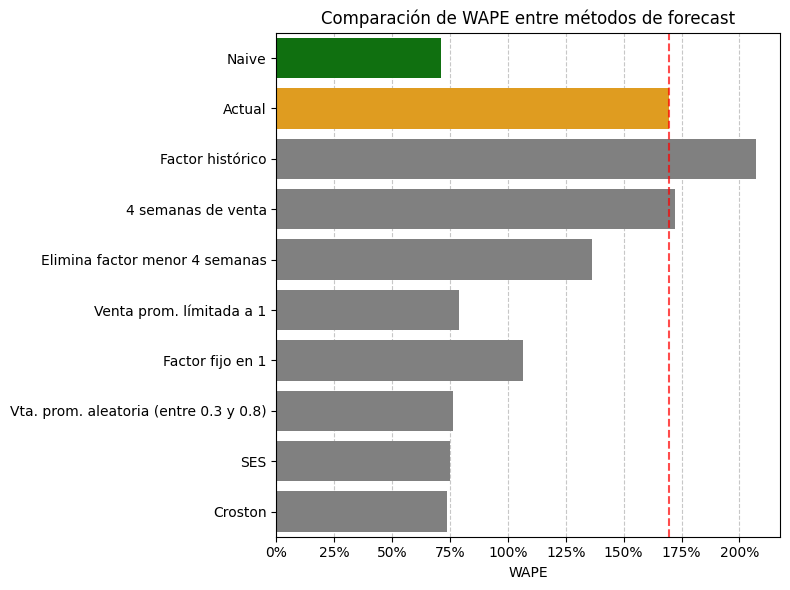

In [239]:
plt.figure(figsize=(8,6))
sns.barplot(data=metrics, x="wape", y="forecast", hue="forecast", palette=colors, legend=False, zorder=2)

# Línea vertical en el valor de Actual
actual_wape = metrics[metrics['forecast'] == 'Actual']['wape'].iloc[0]
plt.axvline(x=actual_wape, color='red', linestyle='--', alpha=0.7)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(0.25))
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.title('Comparación de WAPE entre métodos de forecast')
plt.xlabel('WAPE')
plt.ylabel('')

plt.grid(axis='x', linestyle='--', alpha=0.7, zorder = 1)

plt.tight_layout()
plt.show()

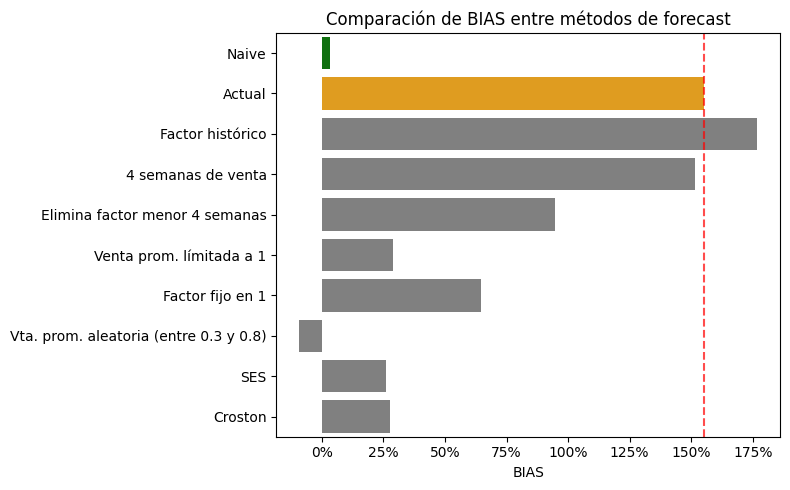

In [240]:
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics, x="bias", y="forecast", hue="forecast", palette=colors, legend=False)

# Línea vertical en el valor de Actual
actual_bias = metrics[metrics['forecast'] == 'Actual']['bias'].iloc[0]
plt.axvline(x=actual_bias, color='red', linestyle='--', alpha=0.7)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(0.25))
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.title('Comparación de BIAS entre métodos de forecast')
plt.xlabel('BIAS')
plt.ylabel('')

plt.tight_layout()
plt.show()

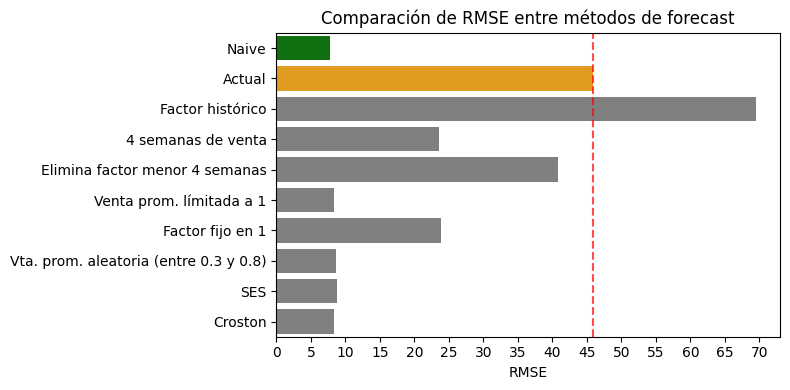

In [241]:
plt.figure(figsize=(8, 4))
sns.barplot(data=metrics, x="rmse", y="forecast", hue="forecast", palette=colors, legend=False)

actual_mae = metrics[metrics['forecast'] == 'Actual']['rmse'].iloc[0]
plt.axvline(x=actual_mae, color='red', linestyle='--', alpha=0.7)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(5))

plt.title('Comparación de RMSE entre métodos de forecast')
plt.xlabel('RMSE')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Temporal

In [242]:
def eval_forecast(df, forecast_dict, group_by_col=None):
   """
   Calcula WAPE, BIAS, MAE y RMSE para cada forecast, opcionalmente agrupado por columna especificada
   usando las funciones definidas y validando con distintas columnas de ventas reales.
   
   Args:
       df (pd.DataFrame): dataframe con ventas reales y forecasts
       forecast_dict (dict): diccionario {forecast_col: real_col}
       group_by_col (str, optional): columna por la cual agrupar. Si None, no agrupa
   
   Returns:
       pd.DataFrame con métricas por método y opcionalmente por grupo
   """
   results = []

   for forecast_col, real_col in forecast_dict.items():
       if group_by_col:
           for group_value, group in df.groupby(group_by_col):
               actual = group[real_col].fillna(0).astype(float)
               forecast = group[forecast_col].fillna(0).astype(float)

               error = forecast - actual
               error_abs = np.abs(error)

               total_error_abs = error_abs.sum()
               total_error = error.sum()
               total_sales = actual.sum()

               results.append({
                   group_by_col: group_value,
                   "forecast": forecast_col,
                   "tipo_venta_real": real_col,
                   "wape": calc_wape(total_error_abs, total_sales),
                   "bias": calc_bias(total_error, total_sales),
                   "mae": calc_mae(error_abs),
                   "rmse": calc_rmse(error)
               })
       else:
           actual = df[real_col].fillna(0).astype(float)
           forecast = df[forecast_col].fillna(0).astype(float)

           error = forecast - actual
           error_abs = np.abs(error)

           total_error_abs = error_abs.sum()
           total_error = error.sum()
           total_sales = actual.sum()

           results.append({
               "forecast": forecast_col,
               "tipo_venta_real": real_col,
               "wape": calc_wape(total_error_abs, total_sales),
               "bias": calc_bias(total_error, total_sales),
               "mae": calc_mae(error_abs),
               "rmse": calc_rmse(error)
           })
   
   return pd.DataFrame(results)

In [243]:
comparative_forecasts = ['forecast_tricot','forecast_naive','forecast_ses','forecast_croston', 'forecast_mauro']

weekly_metrics = eval_forecast(data_repo_x_dda, forecast_dict, group_by_col="week_number")

weekly_metrics = weekly_metrics[weekly_metrics['forecast'].isin(comparative_forecasts)]

weekly_metrics = weekly_metrics[(weekly_metrics['week_number'] <= 12) & (weekly_metrics['week_number'] >= 2)]

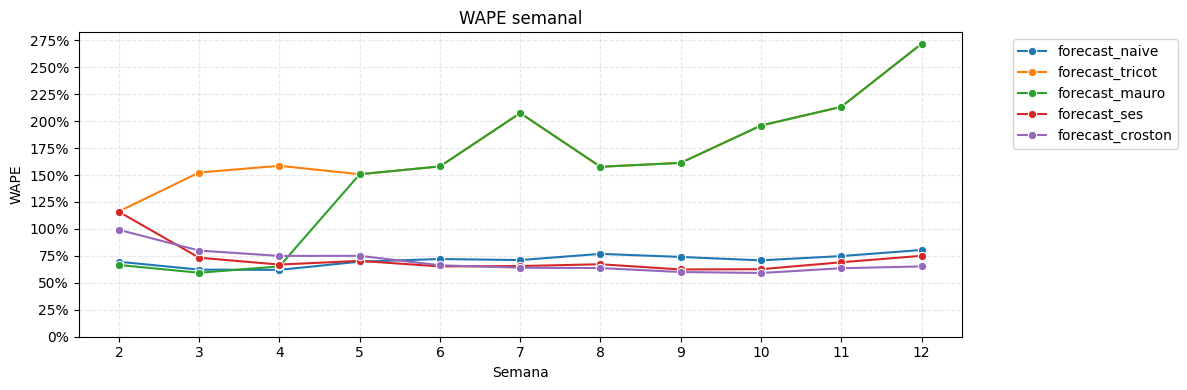

In [244]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as mticker


plt.figure(figsize=(12, 4))

sns.lineplot(x='week_number', y='wape', data=weekly_metrics, hue ='forecast',
             marker = 'o')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xlabel('Semana')

plt.ylim(bottom=0)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.25))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.ylabel('WAPE')


plt.title("WAPE semanal")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

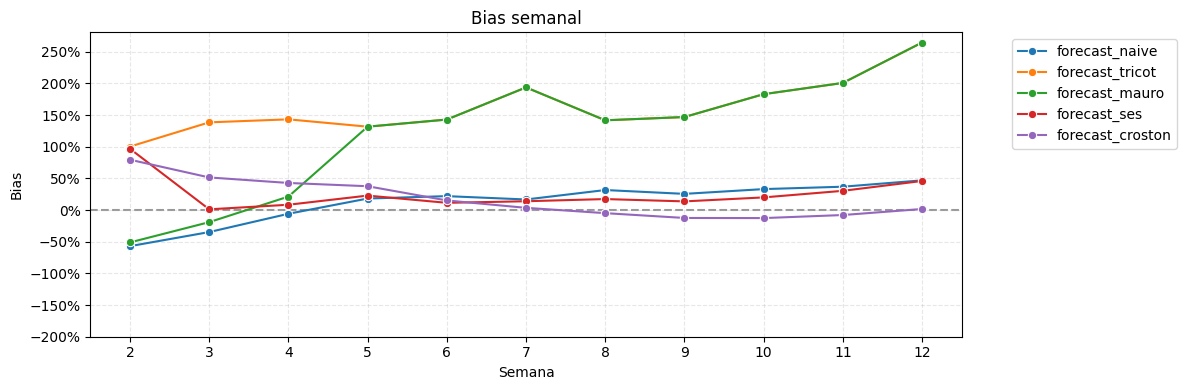

In [245]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

plt.figure(figsize=(12, 4))

sns.lineplot(x='week_number', y='bias', data=weekly_metrics, hue ='forecast',
             marker = 'o', zorder=3)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xlabel('Semana')

plt.ylim(bottom=-2)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.ylabel('Bias')


plt.title("Bias semanal")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

#add black line on y=0
plt.axhline(y=0, color='black', linestyle='--', alpha=0.4, zorder =1)

plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [246]:
depto_metrics = eval_forecast(data_repo_x_dda, forecast_dict, group_by_col="nombre_depto")

depto_metrics = depto_metrics[depto_metrics['forecast'].isin(comparative_forecasts)]

deptos = ['Accesorios', 'Corseteria', 'Deporte hombre', 'Deporte mujer',
       'Formal hombres', 'Juvenil hombres', 'Juvenil mujer', 'Lenceria',
       'Ninas', 'Ninos', 'Sport hombres', 'Sport mujer']


depto_metrics = depto_metrics[depto_metrics['nombre_depto'].isin(deptos)]

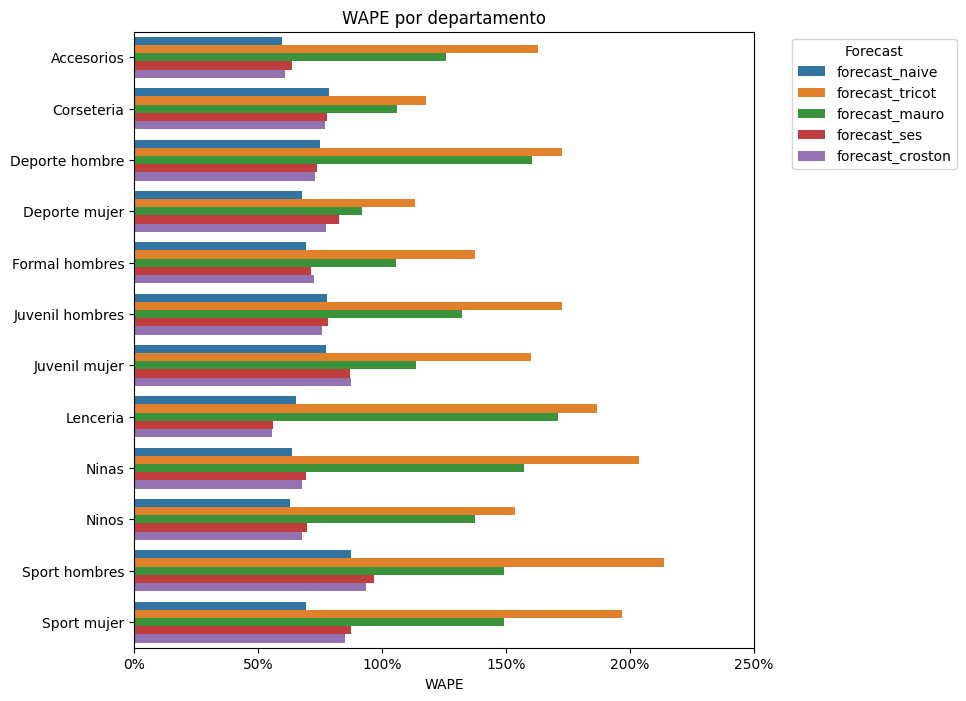

In [247]:
plt.figure(figsize=(8, 8))

sns.barplot(data=depto_metrics, x="wape", y="nombre_depto", hue = 'forecast', legend=True)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.xlim(0, 2.5)

plt.title('WAPE por departamento')
plt.xlabel('WAPE')
plt.ylabel('')

#leyenda
plt.legend(title='Forecast', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

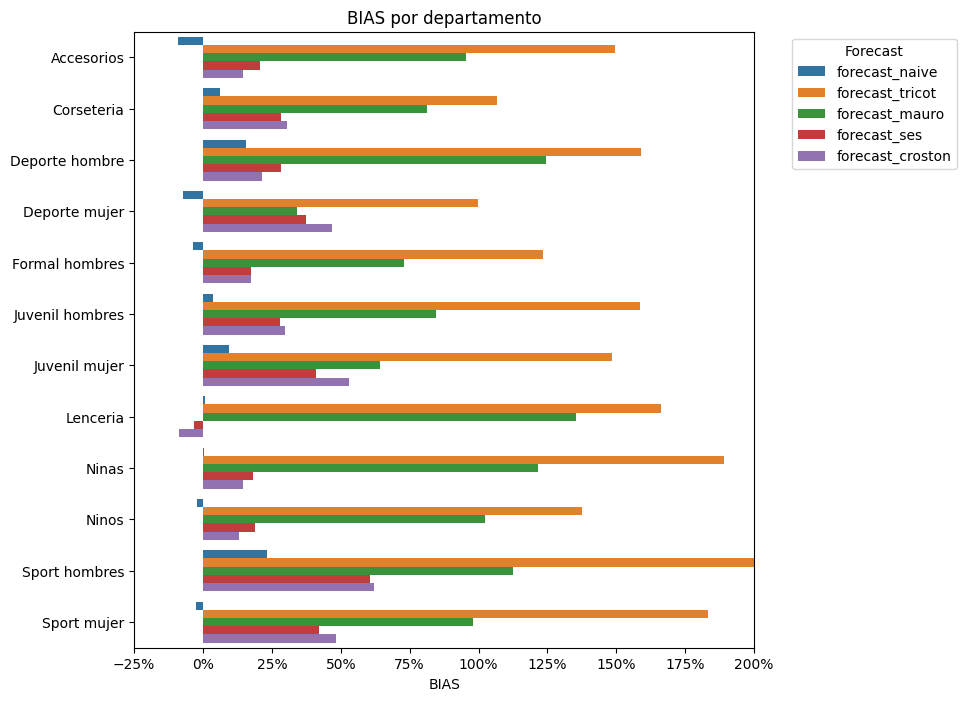

In [248]:
#barplot by depto for the wape

plt.figure(figsize=(8, 8))

sns.barplot(data=depto_metrics, x="bias", y="nombre_depto", hue = 'forecast', legend=True)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(0.25))
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.xlim(-0.25, 2)

plt.title('BIAS por departamento')
plt.xlabel('BIAS')
plt.ylabel('')

#leyenda
plt.legend(title='Forecast', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

# Ejemplo

In [249]:
data_repo_x_dda.groupby(['week_number'])[['vta_promedio', 'SES_mean', 'Croston_mean']].median()

,vta_promedio,SES_mean,Croston_mean
week_number,,,
1,0.8493,0.0000,0.0000
2,1.0000,1.0000,0.9000
3,0.8750,0.4000,0.9000
4,0.7778,0.4000,0.6000
5,0.7778,0.5200,0.5870
6,0.8400,0.4880,0.4910
7,0.8750,0.4930,0.4350
8,0.8400,0.5070,0.3800
9,0.8400,0.5180,0.3415


In [250]:
id = '1273115103'


data_all[data_all['id'] == id][['nombre_sucursal','cod_producto','nom_talla','date','week_number','weekly_available_stock','weekly_sales','can_final','factor','vta_promedio', 'SES_mean', 'Croston_mean', 'forecast_tricot','forecast_ses','forecast_croston']]

KeyError: "['date'] not in index"

In [ ]:
cod_producto = 680279
cod_talla = 105

data_sample = data_repo_x_dda[data_repo_x_dda['cod_producto'] == cod_producto].copy()
data_sample = data_sample[data_sample['cod_talla'] == cod_talla].copy()

In [ ]:
dict_names = {
    "forecast_tricot": "Actual",
    "forecast_factor_hist": "Factor histórico",
    "forecast_sv4": "4 semanas de venta",
    "forecast_vta_promedio": "Venta prom. límitada a 1",
    "forecast_f1": "Factor fijo en 1",
    "forecast_aleatorio": "Aleatorio"
}

In [ ]:
data_sample[['nombre_sucursal','cod_producto','cod_talla','week_number','date', 'can_final','real_sales', 'real_sales_n4',
             'forecast_tricot','forecast_factor_hist', 'forecast_sv4','forecast_vta_promedio','forecast_f1','forecast_aleatorio']].sort_values('can_final', ascending=False)

,nombre_sucursal,cod_producto,cod_talla,week_number,date,can_final,real_sales,real_sales_n4,forecast_tricot,forecast_factor_hist,forecast_sv4,forecast_vta_promedio,forecast_f1,forecast_aleatorio
10733226,FLORIDA CENTER,680279,105,2,2025-03-24,40.0,13,4,45,33,22,11,32,9
21480401,MALL INDEPENDENCIA,680279,105,2,2025-03-24,40.0,9,5,45,33,22,11,32,5
11590134,MAIPU 2,680279,105,2,2025-03-24,37.0,24,6,45,33,22,11,32,9
3862199,CONCEPCION TEATRO,680279,105,2,2025-03-24,33.0,14,4,34,25,17,11,24,8
2623802,OSORNO,680279,105,2,2025-03-24,33.0,3,1,34,25,17,11,24,6
16386159,TOME L,680279,105,2,2025-03-24,33.0,10,3,34,25,17,11,24,4
26611596,MALL PZA EGANA,680279,105,2,2025-03-24,25.0,12,6,34,25,17,11,24,4
18586321,PUENTE,680279,105,2,2025-03-24,21.0,10,3,34,25,17,11,24,8
6959935,SAN VICENTE,680279,105,2,2025-03-24,21.0,12,2,22,17,11,11,16,4
7498496,TALAGANTE,680279,105,2,2025-03-24,21.0,12,4,22,17,11,11,16,3
